In [1]:
!uv pip install SimpleITK monai

Using Python 3.12.13 environment at: /usr
Resolved 32 packages in 363ms
Prepared 2 packages in 1.28s
Installed 2 packages in 24ms
 + monai==1.5.2
 + simpleitk==2.5.5


In [2]:
import warnings
import os
import glob
import zipfile
import random
from pathlib import Path
import torch
import numpy as np

warnings.filterwarnings("ignore", category=UserWarning, message=".*non-tuple sequence for multidimensional indexing.*")
warnings.filterwarnings("ignore", category=FutureWarning, message=".*cuda.cudart module is deprecated.*")
warnings.filterwarnings("ignore", category=FutureWarning, message=".*monai.transforms.*")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## Load MSSEG dataset

In [4]:
MSSEG_TRAIN_ZIP = "/content/drive/MyDrive/MSSEG-Training.zip"
MSSEG_TEST_ZIP = "/content/drive/MyDrive/MSSEG-Testing.zip"
MSSEG_EXTRACT_DIR = "/content/MSSEG-Training"
MSSEG_EXTRACT_DIR_TEST = "/content/MSSEG-Testing"

def unzip_if_needed(zip_path, extract_dir):
    if zip_path and os.path.exists(zip_path):
        marker = Path(extract_dir) / ".extracted"
        if not marker.exists():
            os.makedirs(extract_dir, exist_ok=True)
            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(extract_dir)
            marker.touch()
        return extract_dir
    return extract_dir

def first_match(files, include_terms, exclude_terms=()):
    include_terms = [t.upper() for t in include_terms]
    exclude_terms = [t.upper() for t in exclude_terms]
    candidates = []
    for f in files:
        name = os.path.basename(f).upper()
        if all(t in name for t in include_terms) and not any(t in name for t in exclude_terms):
            candidates.append(f)
    return sorted(candidates)[0] if candidates else None

def find_case_files(case_dir):
    nii_files = glob.glob(os.path.join(case_dir, "**", "*.nii*"), recursive=True)
    if not nii_files:
        return None
    flair = first_match(nii_files, ["FLAIR"])
    t2 = first_match(nii_files, ["T2"], exclude_terms=["T2STAR", "T2_STAR"])
    t1 = first_match(nii_files, ["T1"], exclude_terms=["GADO", "GD", "GAD", "CE", "CONTRAST"])
    label = (first_match(nii_files, ["CONSENSUS"]) or first_match(nii_files, ["LESION"])
             or first_match(nii_files, ["MASK"]) or first_match(nii_files, ["SEG"])
             or first_match(nii_files, ["GT"]))
    image_set = {p for p in [flair, t1, t2] if p}
    if label in image_set:
        label = None
    if flair and t1 and t2 and label:
        return {"flair": flair, "t1": t1, "t2": t2, "label": label}
    return None

def collect_dataset(root_dir, source_name):
    root_dir = str(root_dir)
    if not os.path.exists(root_dir):
        print(f"WARNING: {source_name} root not found: {root_dir}")
        return []
    all_dirs = [root_dir] + [p for p, _, _ in os.walk(root_dir)]
    cases = []
    seen = set()
    for d in all_dirs:
        item = find_case_files(d)
        if item is None:
            continue
        key = tuple(item[k] for k in ["flair", "t1", "t2", "label"])
        if key in seen:
            continue
        seen.add(key)
        item["source"] = source_name
        item["case_id"] = f"{source_name}_{len(cases):03d}"
        cases.append(item)
    return cases

msseg_root = unzip_if_needed(MSSEG_TRAIN_ZIP, MSSEG_EXTRACT_DIR)
msseg_test_root = unzip_if_needed(MSSEG_TEST_ZIP, MSSEG_EXTRACT_DIR_TEST)
msseg_train_files = collect_dataset(msseg_root, "MSSEG_TRAIN")
msseg_test_files = collect_dataset(msseg_test_root, "MSSEG_TEST")

print(f"MSSEG train cases: {len(msseg_train_files)}")
print(f"MSSEG test cases: {len(msseg_test_files)}")

if msseg_train_files:
    print("Example train case:")
    for k, v in msseg_train_files[0].items():
        print(f"  {k}: {v}")
else:
    raise RuntimeError("No complete MSSEG cases found. Check paths.")

MSSEG train cases: 15
MSSEG test cases: 38
Example train case:
  flair: /content/MSSEG-Training/Training/Center_01/Patient_01/Preprocessed_Data/FLAIR_preprocessed.nii.gz
  t1: /content/MSSEG-Training/Training/Center_01/Patient_01/Raw_Data/T1.nii.gz
  t2: /content/MSSEG-Training/Training/Center_01/Patient_01/Preprocessed_Data/T2_preprocessed.nii.gz
  label: /content/MSSEG-Training/Training/Center_01/Patient_01/Masks/Consensus.nii.gz
  source: MSSEG_TRAIN
  case_id: MSSEG_TRAIN_000


## Data Preprocessing & SplitSplit: **12 train / 3 val** from the 15 training cases.The 38 MSSEG_TEST cases are held out for **final evaluation only**.

In [5]:
from sklearn.model_selection import train_test_split
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd,
    NormalizeIntensityd, ConcatItemsd, DeleteItemsd,
    RandCropByPosNegLabeld, EnsureTyped, CropForegroundd,
    RandFlipd, RandRotate90d, RandScaleIntensityd, RandShiftIntensityd,
    RandGaussianNoised, RandBiasFieldd, RandAdjustContrastd, Lambdad,
)
from monai.data import PersistentDataset, DataLoader

def binarize_label(x):
    return (x > 0).astype(x.dtype)

base_transforms = [
    LoadImaged(keys=["flair", "t1", "t2", "label"]),
    EnsureChannelFirstd(keys=["flair", "t1", "t2", "label"]),
    Orientationd(keys=["flair", "t1", "t2", "label"], axcodes="RAS"),
    Spacingd(
        keys=["flair", "t1", "t2", "label"],
        pixdim=(1.0, 1.0, 1.0),
        mode=("bilinear", "bilinear", "bilinear", "nearest"),
        padding_mode="zeros",
    ),
    Lambdad(keys="label", func=binarize_label),
    CropForegroundd(keys=["flair", "t1", "t2", "label"], source_key="flair"),
    NormalizeIntensityd(keys=["flair", "t1", "t2"], nonzero=True, channel_wise=True),
    ConcatItemsd(keys=["flair", "t1", "t2"], name="image", dim=0),
    DeleteItemsd(keys=["flair", "t1", "t2"]),
]

train_transforms = Compose(base_transforms + [
    RandCropByPosNegLabeld(
        keys=["image", "label"], label_key="label",
        spatial_size=(96, 96, 96), pos=5, neg=1,
        num_samples=6, image_key="image", image_threshold=0,
    ),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
    RandRotate90d(keys=["image", "label"], prob=0.25, max_k=3),
    RandScaleIntensityd(keys="image", factors=0.2, prob=0.5),
    RandShiftIntensityd(keys="image", offsets=0.15, prob=0.5),
    RandGaussianNoised(keys="image", prob=0.15, mean=0.0, std=0.01),
    RandBiasFieldd(keys="image", prob=0.15, coeff_range=(0.0, 0.03)),
    RandAdjustContrastd(keys="image", prob=0.2, gamma=(0.8, 1.2)),
    EnsureTyped(keys=["image", "label"]),
])

val_transforms = Compose(base_transforms + [EnsureTyped(keys=["image", "label"])])
test_transforms = Compose(base_transforms + [EnsureTyped(keys=["image", "label"])])

train_files, val_files = train_test_split(msseg_train_files, test_size=3, random_state=SEED)
test_files = msseg_test_files

print(f"Train cases: {len(train_files)}, Val cases: {len(val_files)}, Test cases (held out): {len(test_files)}")

cache_dir_train = "/content/persistent_cache_train"
cache_dir_val = "/content/persistent_cache_val"
cache_dir_test = "/content/persistent_cache_test"

os.makedirs(cache_dir_train, exist_ok=True)
os.makedirs(cache_dir_val, exist_ok=True)
os.makedirs(cache_dir_test, exist_ok=True)

train_ds = PersistentDataset(data=train_files, transform=train_transforms, cache_dir=cache_dir_train)
val_ds = PersistentDataset(data=val_files, transform=val_transforms, cache_dir=cache_dir_val)
test_ds = PersistentDataset(data=test_files, transform=test_transforms, cache_dir=cache_dir_test)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0)

Train cases: 12, Val cases: 3, Test cases (held out): 38


## Data Analysis

Visualizing training sample: MSSEG_TRAIN_013


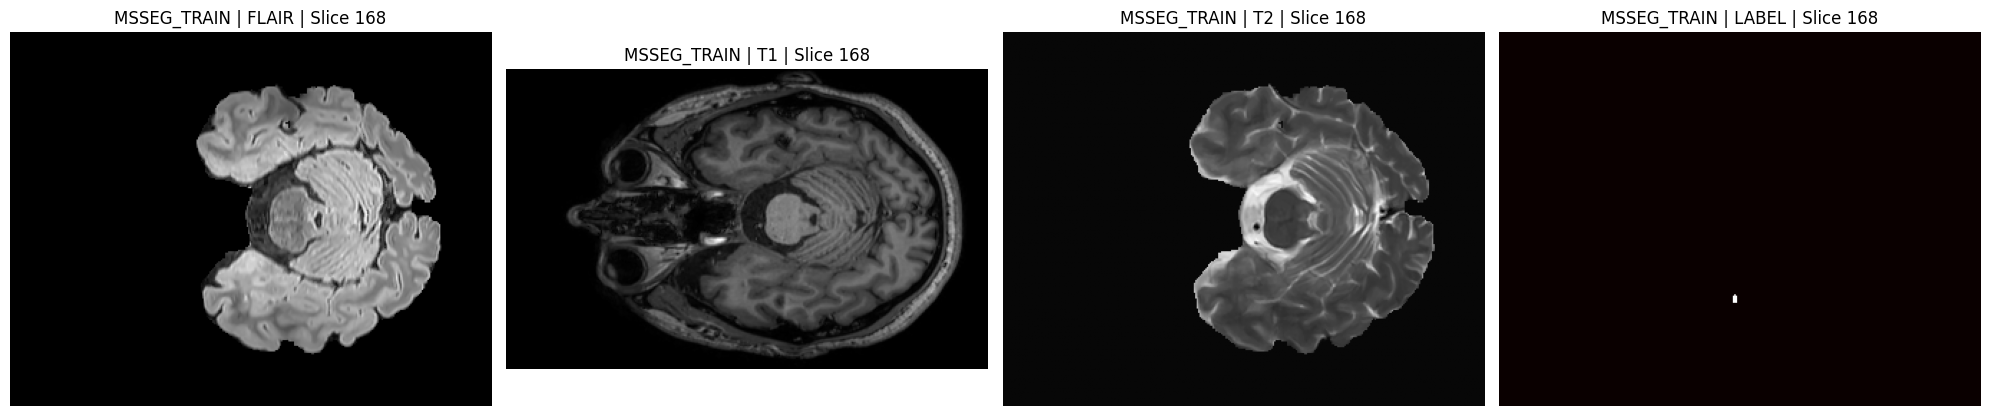

In [6]:
import nibabel as nib
import matplotlib.pyplot as plt

def visualize_sample(sample_dict, slice_idx=None):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    modalities = ["flair", "t1", "t2", "label"]
    for i, mod in enumerate(modalities):
        img = nib.load(sample_dict[mod]).get_fdata()
        current_slice = img.shape[2] // 2 if slice_idx is None else slice_idx
        cmap = "hot" if mod == "label" else "gray"
        title = f"{sample_dict.get('source', 'case')} | {mod.upper()} | Slice {current_slice}"
        axes[i].imshow(img[:, :, current_slice], cmap=cmap)
        axes[i].set_title(title)
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

if train_files:
    cid = train_files[0].get("case_id", "unknown")
    print(f"Visualizing training sample: {cid}")
    visualize_sample(train_files[0])

## Model Architecture (Tri-Encoder with Deep Supervision)

In [7]:
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ConvBlock3D(nn.Module):
    def __init__(self, input_channels, output_channels, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv3d(input_channels, output_channels, kernel_size=3, padding=1, bias=False),
            nn.InstanceNorm3d(output_channels, affine=True),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv3d(output_channels, output_channels, kernel_size=3, padding=1, bias=False),
            nn.InstanceNorm3d(output_channels, affine=True),
            nn.LeakyReLU(0.01, inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout3d(p=dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

class AttentionGate3D(nn.Module):
    def __init__(self, gating_channels, skip_channels, intermediate_channels):
        super().__init__()
        self.W_gating = nn.Sequential(
            nn.Conv3d(gating_channels, intermediate_channels, kernel_size=1, bias=False),
            nn.InstanceNorm3d(intermediate_channels, affine=True),
        )
        self.W_skip = nn.Sequential(
            nn.Conv3d(skip_channels, intermediate_channels, kernel_size=1, bias=False),
            nn.InstanceNorm3d(intermediate_channels, affine=True),
        )
        self.attention_filter = nn.Sequential(
            nn.Conv3d(intermediate_channels, 1, kernel_size=1, bias=True),
            nn.Sigmoid(),
        )
        self.relu = nn.LeakyReLU(0.01, inplace=True)

    def forward(self, gating_signal, skip_connection):
        relevance_map = self.relu(self.W_gating(gating_signal) + self.W_skip(skip_connection))
        attention_coefficients = self.attention_filter(relevance_map)
        return skip_connection * attention_coefficients

class TriEncoderAttentionUNet3D(nn.Module):
    def __init__(self, dropout=0.25):
        super().__init__()
        self.pool = nn.MaxPool3d(kernel_size=2, stride=2)

        self.flair_l1 = ConvBlock3D(1, 16, dropout=0.0)
        self.t1_l1 = ConvBlock3D(1, 16, dropout=0.0)
        self.t2_l1 = ConvBlock3D(1, 16, dropout=0.0)

        self.flair_level_2 = ConvBlock3D(16, 32, dropout=dropout)
        self.t1_level_2 = ConvBlock3D(16, 32, dropout=dropout)
        self.t2_level_2 = ConvBlock3D(16, 32, dropout=dropout)

        self.fuse_l1 = ConvBlock3D(48, 32, dropout=dropout)
        self.fuse_level_2 = ConvBlock3D(96, 64, dropout=dropout)
        self.joint_l3 = ConvBlock3D(64, 128, dropout=dropout)

        self.bottleneck = ConvBlock3D(128, 256, dropout=dropout * 2)

        self.up3 = nn.ConvTranspose3d(256, 128, kernel_size=2, stride=2)
        self.att3 = AttentionGate3D(128, 128, 64)
        self.dec3 = ConvBlock3D(256, 128, dropout=dropout)

        self.up2 = nn.ConvTranspose3d(128, 64, kernel_size=2, stride=2)
        self.att2 = AttentionGate3D(64, 64, 32)
        self.dec2 = ConvBlock3D(128, 64, dropout=dropout)

        self.up1 = nn.ConvTranspose3d(64, 32, kernel_size=2, stride=2)
        self.att1 = AttentionGate3D(32, 32, 16)
        self.dec1 = ConvBlock3D(64, 32, dropout=dropout)

        self.final = nn.Conv3d(32, 1, kernel_size=1)
        self.aux3 = nn.Conv3d(128, 1, kernel_size=1)
        self.aux2 = nn.Conv3d(64, 1, kernel_size=1)

    def forward(self, x, return_aux=True):
        flair_input = x[:, 0:1]
        t1_input = x[:, 1:2]
        t2_input = x[:, 2:3]

        f1 = self.flair_l1(flair_input)
        t1_1 = self.t1_l1(t1_input)
        t2_1 = self.t2_l1(t2_input)
        fused_skip_l1 = self.fuse_l1(torch.cat([f1, t1_1, t2_1], dim=1))

        f2 = self.flair_level_2(self.pool(f1))
        t1_2 = self.t1_level_2(self.pool(t1_1))
        t2_2 = self.t2_level_2(self.pool(t2_1))
        fused_skip_l2 = self.fuse_level_2(torch.cat([f2, t1_2, t2_2], dim=1))

        fused_f3 = self.joint_l3(self.pool(fused_skip_l2))
        bottle = self.bottleneck(self.pool(fused_f3))

        up_l3 = self.up3(bottle)
        att3 = self.att3(up_l3, fused_f3)
        dec_l3 = self.dec3(torch.cat([up_l3, att3], dim=1))

        up_l2 = self.up2(dec_l3)
        att2 = self.att2(up_l2, fused_skip_l2)
        dec_l2 = self.dec2(torch.cat([up_l2, att2], dim=1))

        up_l1 = self.up1(dec_l2)
        att1 = self.att1(up_l1, fused_skip_l1)
        dec_l1 = self.dec1(torch.cat([up_l1, att1], dim=1))

        out_final = self.final(dec_l1)

        if return_aux:
            o3 = F.interpolate(self.aux3(dec_l3), size=out_final.shape[2:], mode="trilinear", align_corners=False)
            o2 = F.interpolate(self.aux2(dec_l2), size=out_final.shape[2:], mode="trilinear", align_corners=False)
            return out_final, o3, o2
        return out_final

model = TriEncoderAttentionUNet3D(dropout=0.25).to(device)
print(f"Tri-Encoder Attention U-Net with Deep Supervision initialized on {device}")

Tri-Encoder Attention U-Net with Deep Supervision initialized on cuda


## Deep-Supervised Loss

In [8]:
from monai.losses import DiceFocalLoss

class DeepSupervisedDiceFocalLoss(nn.Module):
    def __init__(self, lambda_dice=0.7, lambda_focal=0.3):
        super().__init__()
        self.base_loss = DiceFocalLoss(
            sigmoid=True, squared_pred=True,
            lambda_dice=lambda_dice, lambda_focal=lambda_focal
        )
        self.aux_weights = [1.0, 0.3, 0.15]

    def forward(self, logits_list, targets):
        loss = 0.0
        for i, logits in enumerate(logits_list):
            w = self.aux_weights[i]
            if logits.shape[2:] != targets.shape[2:]:
                logits = F.interpolate(logits, size=targets.shape[2:], mode="trilinear", align_corners=False)
            loss += w * self.base_loss(logits, targets)
        normalizer = sum(self.aux_weights[:len(logits_list)])
        return loss / normalizer

criterion = DeepSupervisedDiceFocalLoss(lambda_dice=0.7, lambda_focal=0.3)

#### Training LoopPrints **train loss**, **val loss**, and **val Dice** every epoch.Best model saved by val Dice. Final test evaluation runs after training.

In [9]:
from monai.metrics import DiceMetric
from monai.transforms import AsDiscrete
from monai.inferers import sliding_window_inference
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

max_epochs = 50
roi_size = (96, 96, 96)
sw_batch_size = 2
accumulation_steps = 2
weight_path = "best_tri_encoder_msseg_only.pth"

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
steps_per_epoch = len(train_loader) // accumulation_steps
total_steps = steps_per_epoch * max_epochs
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-4, total_steps=total_steps, pct_start=0.3)
scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

dice_metric = DiceMetric(include_background=False, reduction="mean")
post_pred = AsDiscrete(threshold=0.5)

history_train_loss = []
history_val_loss = []
history_val_dice = []
best_metric = -1

if os.path.exists(weight_path):
    model.load_state_dict(torch.load(weight_path, map_location=device))
    print(f"Loaded existing weights from {weight_path}; continuing training.")

def predict_fn(inputs):
    return sliding_window_inference(
        inputs=inputs, roi_size=roi_size, sw_batch_size=sw_batch_size,
        predictor=lambda x: model(x, return_aux=False), overlap=0.5, mode="gaussian",
    )

def run_validation():
    model.eval()
    dice_metric.reset()
    val_loss_total = 0.0
    with torch.no_grad():
        for val_data in val_loader:
            val_inputs = val_data["image"].to(device)
            val_labels = val_data["label"].to(device)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
                val_logits = predict_fn(val_inputs)
                val_loss_total += criterion((val_logits,), val_labels).item()
            val_probs = torch.sigmoid(val_logits)
            val_outputs_discrete = [post_pred(i) for i in val_probs]
            dice_metric(y_pred=val_outputs_discrete, y=val_labels)
    avg_dice = dice_metric.aggregate().item()
    avg_val_loss = val_loss_total / max(len(val_loader), 1)
    dice_metric.reset()
    return avg_val_loss, avg_dice

for epoch in range(max_epochs):
    model.train()
    epoch_loss = 0.0
    optimizer.zero_grad()
    for step, batch_data in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{max_epochs}", leave=False)):
        inputs = batch_data["image"].to(device)
        labels = batch_data["label"].to(device)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits_final, logits_aux3, logits_aux2 = model(inputs, return_aux=True)
            loss = criterion((logits_final, logits_aux3, logits_aux2), labels)
        scaler.scale(loss).backward()
        if (step + 1) % accumulation_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=12.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()
        epoch_loss += loss.item()

    epoch_loss /= max(step + 1, 1)
    history_train_loss.append(epoch_loss)
    avg_val_loss, avg_val_dice = run_validation()
    history_val_loss.append(avg_val_loss)
    history_val_dice.append(avg_val_dice)

    current_lr = optimizer.param_groups[0]["lr"]
    if (epoch + 1) % 10 == 0 or epoch == 0 or (epoch + 1) == max_epochs:
        print(f"Epoch [{epoch+1}/{max_epochs}]  Train Loss: {epoch_loss:.4f}  Val Loss: {avg_val_loss:.4f}  Val Dice: {avg_val_dice:.4f}  LR: {current_lr:.2e}")

    if avg_val_dice > best_metric:
        best_metric = avg_val_dice
        torch.save(model.state_dict(), weight_path)
        print(f"  *** New Best Val Dice ({best_metric:.4f}) at epoch {epoch+1} - Model Saved ***")

print(f"Training complete. Best Val Dice: {best_metric:.4f}")

Loaded existing weights from best_tri_encoder_msseg_only.pth; continuing training.


Epoch 1/50:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch [1/50]  Train Loss: 0.2948  Val Loss: 0.2822  Val Dice: 0.8139  LR: 5.07e-06
  *** New Best Val Dice (0.8139) at epoch 1 - Model Saved ***


Epoch 2/50:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 3/50:   0%|          | 0/12 [00:00<?, ?it/s]

...

Epoch 47/50:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 48/50:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 49/50:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 50/50:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch [50/50]  Train Loss: 0.2369  Val Loss: 0.2391  Val Dice: 0.8173  LR: 5.99e-09
Training complete. Best Val Dice: 0.8197


## Final Test Evaluation

In [10]:
from monai.metrics import DiceMetric
from monai.transforms import AsDiscrete
from monai.inferers import sliding_window_inference
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

post_pred = AsDiscrete(threshold=0.5)
roi_size = (96, 96, 96)
sw_batch_size = 2
accumulation_steps = 2

weight_path = "best_tri_encoder_msseg_only.pth"

model.load_state_dict(torch.load(weight_path, map_location=device))
model.eval()
test_dice_metric = DiceMetric(include_background=False, reduction="mean")
case_scores = []

with torch.no_grad():
    for test_data in tqdm(test_loader, desc="Testing on MSSEG_TEST"):
        test_inputs = test_data["image"].to(device)
        test_labels = test_data["label"].to(device)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            test_logits = sliding_window_inference(
                test_inputs, roi_size, sw_batch_size,
                lambda x: model(x, return_aux=False), overlap=0.5, mode="gaussian"
            )
        test_probs = torch.sigmoid(test_logits)
        test_outputs_discrete = [post_pred(i) for i in test_probs]

        case_metric = DiceMetric(include_background=False, reduction="mean")
        case_metric(y_pred=test_outputs_discrete, y=test_labels)
        case_dice = case_metric.aggregate().item()
        case_scores.append(case_dice)

        test_dice_metric(y_pred=test_outputs_discrete, y=test_labels)
        cid = test_data.get("case_id", ["unknown"])[0]
        if isinstance(cid, (list, tuple)):
            cid = cid[0]

avg_test_dice = test_dice_metric.aggregate().item()
print(f"FINAL TEST DICE (MSSEG_TEST, 38 cases): {avg_test_dice:.4f}")
print(f"Best single-case Dice: {max(case_scores):.4f}")
print(f"Worst single-case Dice: {min(case_scores):.4f}")
print(f"Std Dev: {np.std(case_scores):.4f}")

Testing on MSSEG_TEST:   0%|          | 0/38 [00:00<?, ?it/s]

FINAL TEST DICE (MSSEG_TEST, 38 cases): 0.6455
Best single-case Dice: 0.8541
Worst single-case Dice: 0.0000
Std Dev: 0.2143


## Training Curves

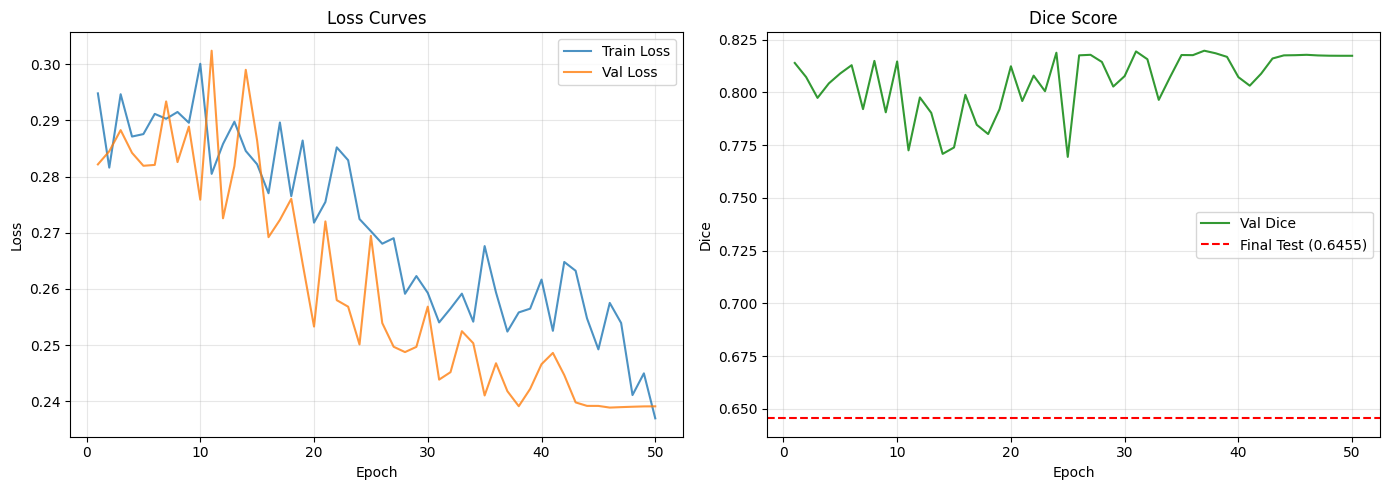

In [11]:
epochs_range = range(1, len(history_train_loss) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history_train_loss, label="Train Loss", alpha=0.8)
axes[0].plot(epochs_range, history_val_loss, label="Val Loss", alpha=0.8)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curves")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history_val_dice, label="Val Dice", color="green", alpha=0.8)
axes[1].axhline(y=avg_test_dice, color="red", linestyle="--", label=f"Final Test ({avg_test_dice:.4f})")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Dice")
axes[1].set_title("Dice Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Test-Time Augmentation (TTA)
We define a TTA function that performs horizontal and vertical flips to create a more robust ensemble prediction for each test volume.

In [13]:
def predict_tta(inputs, model, roi_size, sw_batch_size):
    model.eval()
    with torch.no_grad():
        # 1. Original prediction
        pred = sliding_window_inference(inputs, roi_size, sw_batch_size, lambda x: model(x, return_aux=False), overlap=0.5, mode="gaussian")

        # 2. Flip Axial
        pred += torch.flip(sliding_window_inference(torch.flip(inputs, [2]), roi_size, sw_batch_size, lambda x: model(x, return_aux=False), overlap=0.5), [2])

        # 3. Flip Sagittal
        pred += torch.flip(sliding_window_inference(torch.flip(inputs, [3]), roi_size, sw_batch_size, lambda x: model(x, return_aux=False), overlap=0.5), [3])

        # 4. Flip Coronal
        pred += torch.flip(sliding_window_inference(torch.flip(inputs, [4]), roi_size, sw_batch_size, lambda x: model(x, return_aux=False), overlap=0.5), [4])

    return pred / 4.0

### Final Test Evaluation with TTA
Now we re-run the evaluation on the 38 test cases using the TTA strategy.

In [14]:
test_dice_metric_tta = DiceMetric(include_background=False, reduction="mean")
case_scores_tta = []

with torch.no_grad():
    for test_data in tqdm(test_loader, desc="Testing with TTA"):
        test_inputs = test_data["image"].to(device)
        test_labels = test_data["label"].to(device)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            test_logits = predict_tta(test_inputs, model, roi_size, sw_batch_size)

        test_probs = torch.sigmoid(test_logits)
        test_outputs_discrete = [post_pred(i) for i in test_probs]

        case_metric = DiceMetric(include_background=False, reduction="mean")
        case_metric(y_pred=test_outputs_discrete, y=test_labels)
        case_scores_tta.append(case_metric.aggregate().item())
        test_dice_metric_tta(y_pred=test_outputs_discrete, y=test_labels)

avg_test_dice_tta = test_dice_metric_tta.aggregate().item()

print(f"FINAL TEST DICE WITH TTA: {avg_test_dice_tta:.4f} (Prev: {avg_test_dice:.4f})")
print(f"Best single-case Dice: {max(case_scores_tta):.4f}")
print(f"Worst single-case Dice: {min(case_scores_tta):.4f}")

Testing with TTA:   0%|          | 0/38 [00:00<?, ?it/s]


FINAL TEST DICE WITH TTA: 0.6528 (Prev: 0.6455)
Best single-case Dice: 0.8564
Worst single-case Dice: 0.0000
